In [7]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# # # # # # # # # # # 
tag = '2022041804_04' 

which_train = '01'
which_test = '01'

use_losses = ['SupCon','Recon']
bs = 32
n_epochs = 30
normed_latent = True
use_cuda = False
# # # # # # # # # # # 

In [9]:
%%capture
import torch.nn as nn
import torch
from seqAE_model import SeqAutoencoder
from contra_seq_dataset import ContraSeqDataset

def eval_loss_plot(tag, which_train, use_losses, bs, n_epochs, 
                   use_cuda=False, empty_cuda=False, cuda_ids=[]):
    
    anc_path = f'data/model_ready/{which_train}/train/anchor_smiles.csv'
    aug_path = f'data/model_ready/{which_train}/train/augmented_smiles.csv'

    ds = ContraSeqDataset(anc_path, aug_path)
    model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                           dim_emb=512, heads=8, dim_hidden=32,
                           L_enc=6, L_dec=6, dim_ff=2048, 
                           drpt=0.1, actv='relu', eps=0.6, b_first=True)

    p = f'results/models/{tag}/{n_epochs-1:02}.pt'
    model.load_state_dict(torch.load(p), strict = False)
    print(f"Loaded model weights {p}")
    
    if empty_cuda:
        torch.cuda.empty_cache()

    if use_cuda:
        if len(cuda_ids) == 1:
            cuda_id = cuda_ids[0]
            device = torch.device(f"cuda:{cuda_id}")
        elif len(cuda_ids) > 1:
            device =  torch.device("cuda")
            print("Let's use", len(cuda_ids), "GPUs!")
            model = nn.DataParallel(model, device_ids=cuda_ids)
            model.to(device)
    else:
        device = torch.device("cpu")
        model = model.to(device)

    model.eval()
    
    draw_loss_plot(tag, use_losses, bs, n_epochs, y_lim=(0,5), figsize=(12.5,5), save=True)

In [10]:
tag = '2022041804_04' 
which_train = '01'
use_losses = ['SupCon','Recon']
bs = 32
n_epochs = 30
eval_loss_plot(tag, which_train, use_losses, bs, n_epochs, 
               use_cuda=False, empty_cuda=False, cuda_ids=[])

Loaded model weights results/models/2022041804_04/29.pt


In [ ]:
    device =  torch.device("cuda" if use_cuda else "cpu")
    # device = torch.device("cuda:3")

In [5]:
%%capture
import torch.nn as nn
import torch
from seqAE_model import SeqAutoencoder
from contra_seq_dataset import ContraSeqDataset

anc_path = f'data/model_ready/{which_train}/train/anchor_smiles.csv'
aug_path = f'data/model_ready/{which_train}/train/augmented_smiles.csv'

ds = ContraSeqDataset(anc_path, aug_path)

model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

p = f'results/models/{tag}/{n_epochs-1:02}.pt'
model.load_state_dict(torch.load(p), strict = False)
print(f"Loaded model weights {p}")

# torch.cuda.empty_cache()

device =  torch.device("cuda" if use_cuda else "cpu")
# device = torch.device("cuda:3")
if use_cuda==True and torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model, device_ids)
    model.to(device)
else:
    model = model.to(device)

model.eval()

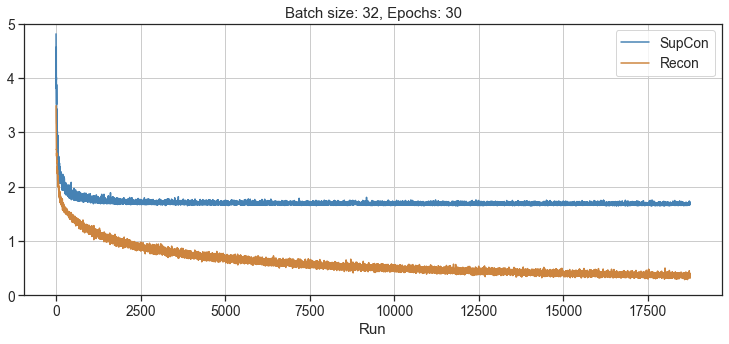

In [6]:
from utilities.plot_utils import draw_loss_plot
draw_loss_plot(tag, use_losses, bs, n_epochs, y_lim=(0,5), figsize=(12.5,5), save=True)